In [27]:
import os
import numpy as np
import shutil
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow import keras

### Reorganizar el dataset
Todas las imagenes están  en 11_RNA_dogs-vs-cats así que see incluye una verificación de la estructura de carpetas para comprobar la correcta separación de imagenes y se renombran a all_images para crear un nuevo trai/, test/. Esto solo va a funcionar la primera vez, una vez validada se comenta (se elimina del flujo), ya que se moverán los archivos de all_images a train/ test/.  
Para poder utilizar la clase de `ImageDataGenerator` de Keras y su finción `flow_from_directory()` es necesario que las imagenes esten organizadas en carpetas separadas por entrenamiento y prueba. De esta manera, Keras podrá etiquetar las imagenes de manera automática y  cargar progresivamente, sin necesidad de almacenar las 25k imágenes en memoria, lo cual es especialmente útil en un entorno como GitHub Codespaces.
Por otra parte se ha usado Sklearn, aunque no necesario, para realizar la separación de forma sencilla, controlada y reproducible, fijando una semilla y estableciendo la proporción 80/20. Manteniendo un balance adecuado entre clases y evitando posibles sesgos. 

In [28]:
# carpeta base del proyecto de imagenes
base_dir = "../data/raw/11_RNA_dogs-vs-cats"

In [29]:
"""
# carpeta donde ahora están todas las imagenes mezcladas
old_src_dir = os.path.join(base_dir, "train")         # 11_RNA_dogs-vs-cats/train

# renombro esa carpeta a 'all_images' para usar 'train' y 'test' como destino
src_dir = os.path.join(base_dir, "all_images")
if not os.path.exists(src_dir):
    os.rename(old_src_dir, src_dir)   # solo la primera vez

src_dir

# Creo la estructura final train/test + cats/dogs
train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")

train_cats = os.path.join(train_dir, "cats")
train_dogs = os.path.join(train_dir, "dogs")
test_cats  = os.path.join(test_dir,  "cats")
test_dogs  = os.path.join(test_dir,  "dogs")

for folder in [train_cats, train_dogs, test_cats, test_dogs]:
    os.makedirs(folder, exist_ok=True)

"carpetas creadas"

# Listar imágenes por clase diferenciando por su nombre
all_files = [f for f in os.listdir(src_dir) if f.endswith(".jpg")]
cat_images = [f for f in all_files if f.lower().startswith("cat")]
dog_images = [f for f in all_files if f.lower().startswith("dog")]

(len(cat_images), len(dog_images))

# Split con sklearn (80% train, 20% test)
cat_train, cat_test = train_test_split(cat_images, test_size=0.2, random_state=42)
dog_train, dog_test = train_test_split(dog_images, test_size=0.2, random_state=42)

(len(cat_train), len(cat_test), len(dog_train), len(dog_test))

# función para mover archivos
def mover(lista, destino):
    for fname in lista:
        shutil.move(os.path.join(src_dir, fname), os.path.join(destino, fname))

# Muevo cada grupo a su carpeta
mover(cat_train, train_cats)
mover(cat_test,  test_cats)
mover(dog_train, train_dogs)
mover(dog_test,  test_dogs)

"Dataset organizado correctamente"

tree_lines = []
for root, dirs, files in os.walk(base_dir):
    level = root.replace(base_dir, "").count(os.sep)
    indent = "  " * level
    tree_lines.append (f"{indent}{os.path.basename(root)}/({len(files)} ficheros)")

"\n".join(tree_lines)

"""

'\n# carpeta donde ahora están todas las imagenes mezcladas\nold_src_dir = os.path.join(base_dir, "train")         # 11_RNA_dogs-vs-cats/train\n\n# renombro esa carpeta a \'all_images\' para usar \'train\' y \'test\' como destino\nsrc_dir = os.path.join(base_dir, "all_images")\nif not os.path.exists(src_dir):\n    os.rename(old_src_dir, src_dir)   # solo la primera vez\n\nsrc_dir\n\n# Creo la estructura final train/test + cats/dogs\ntrain_dir = os.path.join(base_dir, "train")\ntest_dir  = os.path.join(base_dir, "test")\n\ntrain_cats = os.path.join(train_dir, "cats")\ntrain_dogs = os.path.join(train_dir, "dogs")\ntest_cats  = os.path.join(test_dir,  "cats")\ntest_dogs  = os.path.join(test_dir,  "dogs")\n\nfor folder in [train_cats, train_dogs, test_cats, test_dogs]:\n    os.makedirs(folder, exist_ok=True)\n\n"carpetas creadas"\n\n# Listar imágenes por clase diferenciando por su nombre\nall_files = [f for f in os.listdir(src_dir) if f.endswith(".jpg")]\ncat_images = [f for f in all_files

Con `flow_fromdirectory()` se leeran las imagenes de train por lotes, redimensionandolas a un tamaño fijo de 200x200 píxeles y normalizando al un rango [0,1], además las etiquetas se asignan automáticamente en función del nombre de las carpetas. El mapeo de clases se comprueba a través de `class_indices` que indica qué valor corresponde a cada clase y se utilizará en el entrenamiento y en la interpretación de las predicciones     

In [30]:
# rutas a carpetas
train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")

# asignación de rango
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

BATCH_SIZE=8 #limitacion máquina

trdata = train_datagen.flow_from_directory(train_dir,
                                           target_size=(200, 200),
                                           batch_size=BATCH_SIZE,
                                           class_mode="binary")

tsdata = test_datagen.flow_from_directory(test_dir,
                                          target_size=(200, 200),
                                          batch_size=BATCH_SIZE,
                                          class_mode="binary",
                                          shuffle=False)#ordenestable
trdata.class_indices, trdata.image_shape


Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


({'cats': 0, 'dogs': 1}, (200, 200, 3))

##### Visualización
Pasamos a visualizar los datos directamente desde `ImageDataGenerator` para comprobar que las imagenes se cargan correctamente, la visualización se realiza por lotes generados anteriormente por `flow_from_directory()` 

Found 20000 images belonging to 2 classes.


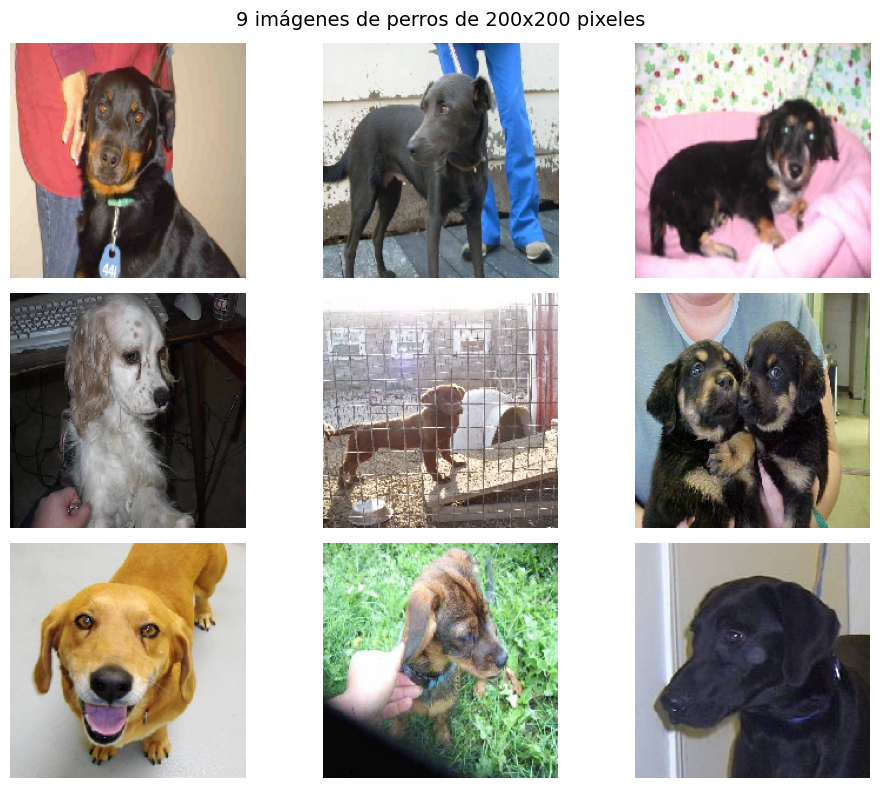

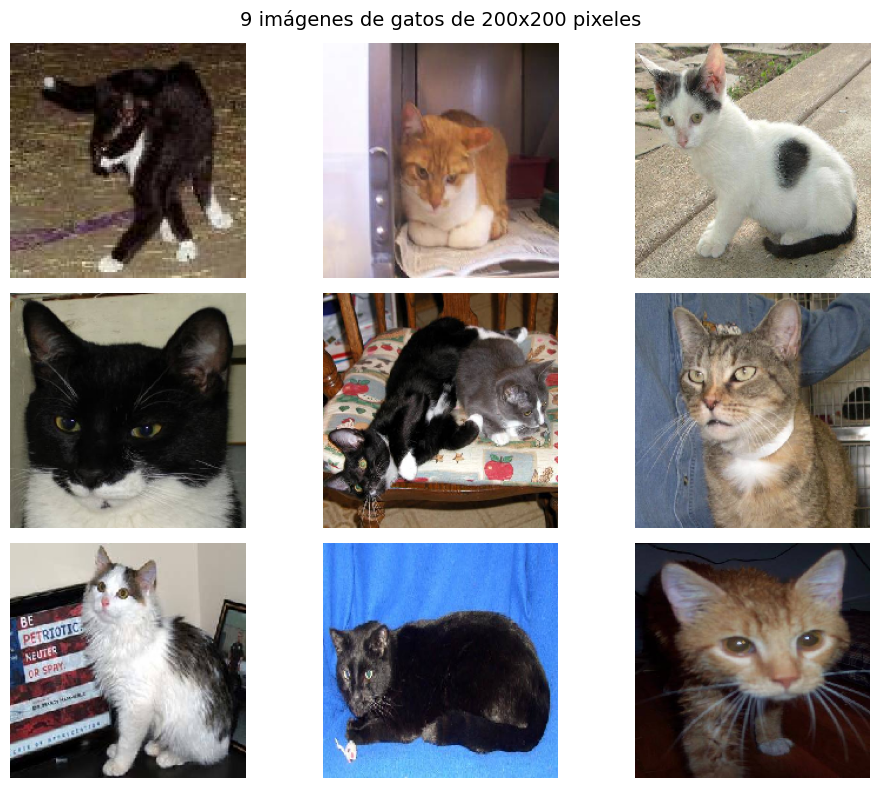

In [31]:
#generador solo para visualización 
vis_data = ImageDataGenerator(rescale=1./255).flow_from_directory(train_dir,
                                                                  target_size=(200,200),
                                                                  batch_size=64,#asegurar 9 imagenes
                                                                  class_mode="binary",
                                                                  shuffle=True)

#obtener lotes de imágenes y etiquetas
X_batch, y_batch = next(vis_data)

#mapeo de clases
class_indices = vis_data.class_indices
cat_label = class_indices["cats"]
dog_label = class_indices["dogs"]

# seleccionar 9 imagenes de perros y 9 de gatos de los lotes
cats = X_batch[y_batch == cat_label][:9]
dogs = X_batch[y_batch == dog_label][:9]

# visualizción perros
plt.figure(figsize=(10,8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(dogs[i])    
    plt.axis("off")

plt.suptitle("9 imágenes de perros de 200x200 pixeles", fontsize=14)
plt.tight_layout()
plt.show()

# seleccionar 9 imagenes de perros y 9 de gatos de los lotes
cats = X_batch[y_batch == cat_label][:9]
dogs = X_batch[y_batch == dog_label][:9]

# visualización gatos
plt.figure(figsize=(10,8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(cats[i])    
    plt.axis("off")

plt.suptitle("9 imágenes de gatos de 200x200 pixeles", fontsize=14)
plt.tight_layout()
plt.show()

##### Construcción de la RNA

In [32]:
model = Sequential()
model.add(Conv2D(input_shape=(200,200,3), filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

#en vez de Flatten + Dense(4096), usamos esto (mucho más ligero)
model.add(GlobalAveragePooling2D())
model.add(Dense(256, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

model.compile(loss="binary_crossentropy",
              optimizer=Adam(learning_rate=1e-4),
              metrics=["accuracy"])

model.summary()

# Entrenamiento “prueba” rápido

history = model.fit(trdata,
                    epochs=1,
                    steps_per_epoch=100,
                    validation_data=tsdata,
                    validation_steps=20)

/home/vscode/.local/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 14,846,273 (56.63 MB)

 Non-trainable params: 0 (0.00 B)

100/100 ━━━━━━━━━━━━━━━━━━━━ 532s 5s/step - accuracy: 0.5337 - loss: 0.6947 - val_accuracy: 1.0000 - val_loss: 0.6841


##### Optimización

Para la optimización del proceso se usa `ModelCheckpoint` y `EarlyStopping`, los cuales respectivamente guardará el mejor modelo y parará el modelo cuando no mejoren los resultados. Si quisieramos optimizar el modelo deberiamos usar métodos como `Data Augmentation` para aplicar transformaciones a las imagenes de entrenamiento.

In [33]:
checkpoint = ModelCheckpoint(filepath="../models/best_dogs_cats.keras", #ruta
                             monitor="val_accuracy", #metrica a tener en cuenta
                             mode="max", #maximizar val_accuracy
                             save_best_only=True, #solo guarda si mejora el modelo respecto al anterior
                             verbose=1) #muestra mensajes de monitorización

earlystop = EarlyStopping(monitor="val_accuracy", #observar accurcy validación
                          mode="max", #Que suba val_accuracy
                          patience=3, #tiempo de espera de epochs para detener sin mejora
                          restore_best_weights=True, #al parar, vuelve a los mejores pesos, no a los últimos
                          verbose=1)

history_opt_proces = model.fit(trdata,
                               epochs=20,# EarlyStopping parará antes
                               steps_per_epoch=25,
                               validation_data=tsdata,
                               validation_steps=10,
                               callbacks=[checkpoint, earlystop])

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4786 - loss: 0.6937
Epoch 1: val_accuracy improved from None to 1.00000, saving model to ../models/best_dogs_cats.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 137s 5s/step - accuracy: 0.5000 - loss: 0.6936 - val_accuracy: 1.0000 - val_loss: 0.6833
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5036 - loss: 0.6932
Epoch 2: val_accuracy did not improve from 1.00000
25/25 ━━━━━━━━━━━━━━━━━━━━ 141s 6s/step - accuracy: 0.5200 - loss: 0.6929 - val_accuracy: 1.0000 - val_loss: 0.6815
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4684 - loss: 0.6940
Epoch 3: val_accuracy did not improve from 1.00000
25/25 ━━━━━━━━━━━━━━━━━━━━ 138s 6s/step - accuracy: 0.4800 - loss: 0.6937 - val_accuracy: 1.0000 - val_loss: 0.6824
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3853 - loss: 0.6952
Epoch 4: val_accuracy did not improve from 1.00000
25/25 ━━━━━━━━━━━━━━━━━━━━ 141s 6s/step - accuracy: 0.4350 - loss: 

#### Conclusión

Debido a las limitaciones de hardware del entorno de ejecución (Github Codespaces con 8Gb deRAM) y con el fin de demostrar que el pipeline funciona sin usar IDEs externos como VSCode, el entrenamiento y la validación se han realizado utilizando un numero limitado de lotes por época (step_per_epoch y validation_steps).

Este planteamiento permite entrenar el modelo de forma estable  sin cargar el conjunto completo de imágenes en memoria evitando prblemas de rendimiento o caida del kernel.

Las metricas de validación se calculan únicamente sobre un subconjunto reducido del conjunto de test. Por este motivo, valores como `val_accuracy =1.0` no deben interpretarse como medida definitiva del rendimiento global del modelo, si no como referencia del correcto funcionamiento del pproceso de entrenamiento y del los mecanismos de optimización del proceso (callbacks).

La cercania de la accuracy de entrenamiento a 0.5 y una perdida (loss) próxima a 0.69 indican que el modelo aun no ha aprendido lo suficiente, lo que es normal con los pocos datos establecidos por época y con la complejidad de un problema de clasificación de imagenes.

Para obtener una evaluación mñas realista del rendimiento del modelo será necesario entrenar más épocas y validar sobre el conjunto de test, y/o aplicar diferentes técnicas de optimización del modelo como `transfer learning` o `data augmentation`, lo cual queda fuera del alcance de este entorno de ejecución.  